# General notebook

In [74]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


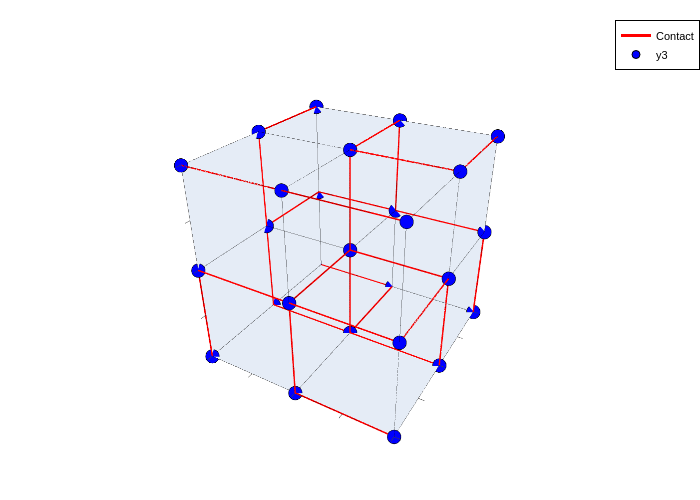

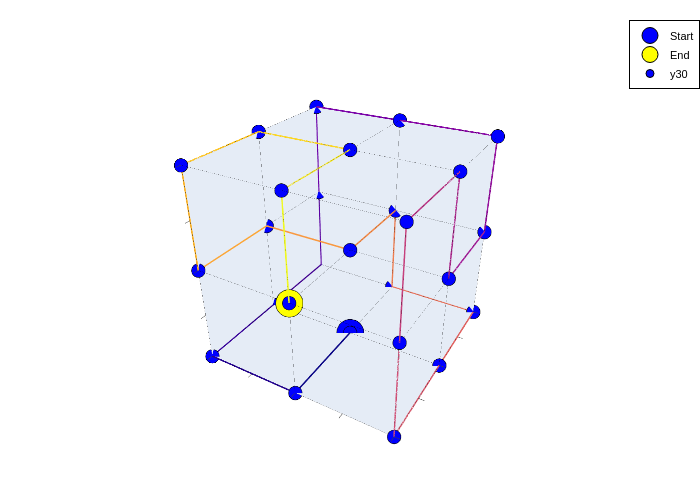

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut tester MJ*5 il faut restart le kernel et modifier la ligne const dans le ficher file_metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:41


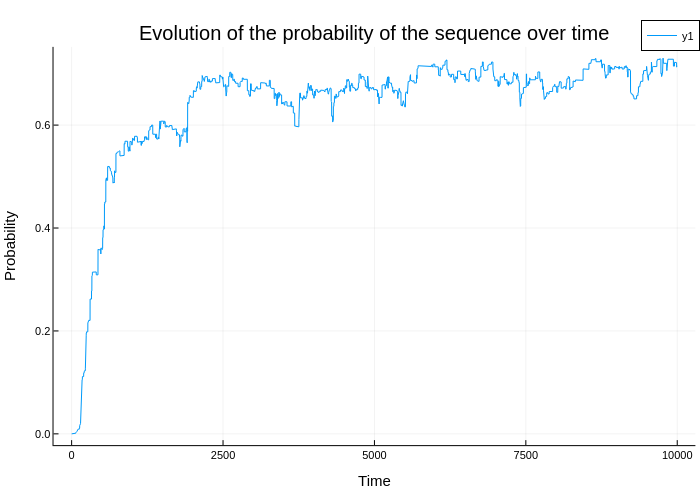

In [4]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


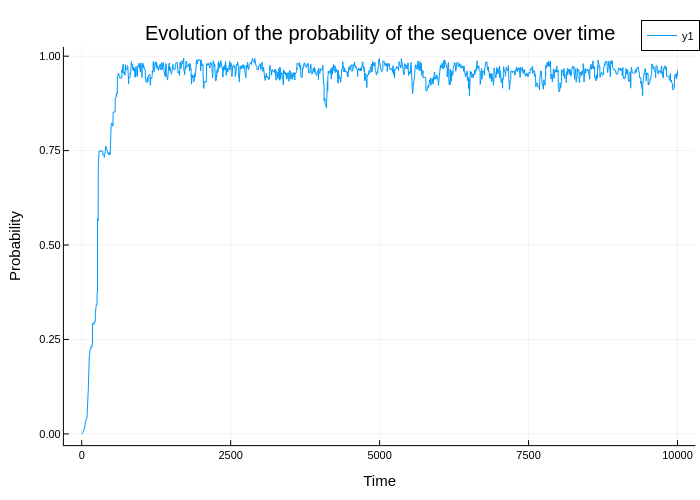

In [5]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:01


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:01


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:01


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:01


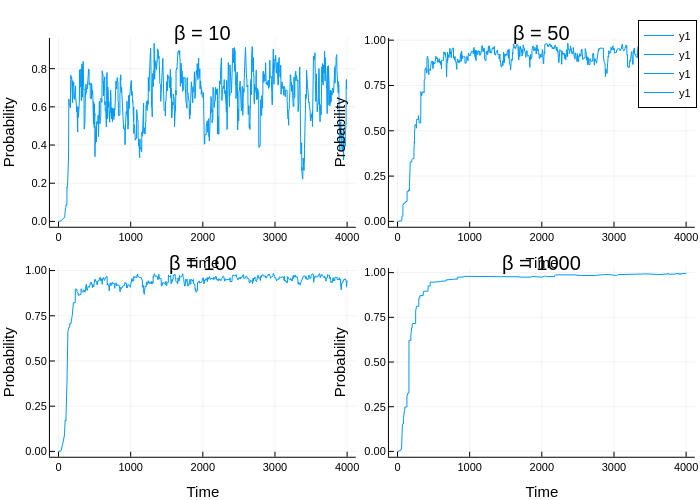

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([2, 7, 16, 13, 15, 19, 19, 19, 19, 17  …  1, 17, 15, 19, 4, 19, 19…
  10.0   => ([11, 7, 8, 3, 20, 16, 5, 16, 3, 3  …  12, 7, 19, 15, 15, 9, 16, 18…
  1000.0 => ([18, 1, 16, 15, 1, 14, 18, 1, 1, 16  …  1, 18, 16, 19, 5, 18, 19, …
  100.0  => ([5, 5, 6, 19, 5, 16, 15, 9, 1, 5  …  1, 1, 19, 16, 3, 16, 15, 4, 1…

In [6]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:38


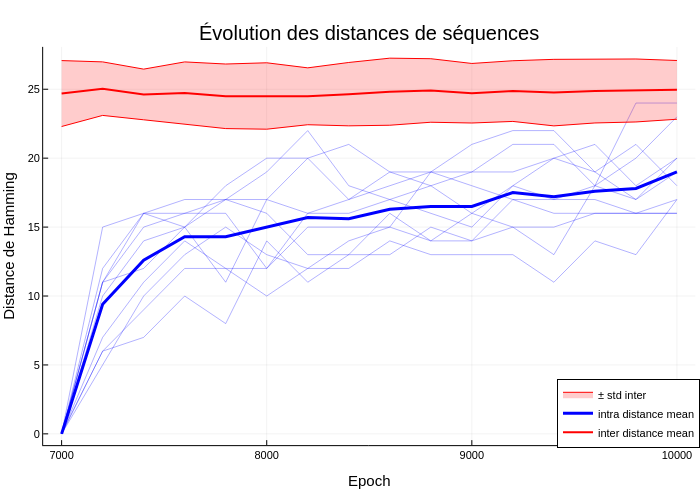

In [7]:
paths_reduced = reduce_data(PATHS, 10)
beta = 1000.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=10000, beta=beta, threshold=7000, step=200, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [8]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


structure 1234 : 0.9787460716200883
structure 1233 : 0.0038048335056433337
structure 1558 : 0.0019862972628998865
structure 529 : 0.001797276086814238
structure 493 : 0.001331454872707519
structure 2332 : 0.0013314548727075186
structure 1797 : 0.0009382603907949483
structure 6271 : 0.0008489731094523057
structure 3401 : 0.0008489731094523006
structure 5179 : 0.0006611809224480248
structure 6268 : 0.0006289347483510833
structure 6456 : 0.00042158756946811184
structure 7617 : 0.00040102650108180346
structure 5089 : 0.00036286378380285357
structure 1166 : 0.00032833272923493576
structure 496 : 0.00025570578663613704
structure 3928 : 0.00024323486826339927
structure 1662 : 0.00023137216375669818
structure 999 : 0.0002093541912590021
structure 5828 : 0.0001630452080917919


In [69]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)

root,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)
newick, seq_dict = create_genealogy(root, 50, 2, target_number, all_ctc_maps)

println(newick)

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

for node in nodes(tree)
    name = label(node)
    println("$name : $(seq_dict[name])")
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


((N3:50,N4:50)N2:50,(N6:50,N7:50)N5:50)N1;
N3 : [2, 16, 17, 18, 19, 12, 9, 16, 18, 19, 7, 4, 9, 19, 16, 3, 18, 15, 15, 16, 17, 4, 18, 19, 5, 16, 6]
N4 : [1, 16, 10, 7, 19, 12, 9, 16, 18, 19, 7, 4, 9, 19, 16, 4, 18, 16, 15, 16, 19, 6, 18, 19, 5, 16, 15]
N5 : [20, 16, 6, 6, 19, 18, 9, 16, 19, 18, 7, 6, 4, 19, 15, 2, 18, 16, 15, 16, 17, 4, 12, 18, 7, 16, 2]
N7 : [13, 16, 6, 18, 19, 9, 15, 16, 19, 18, 20, 6, 4, 18, 15, 1, 18, 16, 15, 16, 17, 4, 12, 18, 4, 16, 5]
N1 : [20, 16, 6, 18, 19, 12, 9, 16, 18, 19, 7, 9, 4, 19, 15, 4, 18, 16, 15, 16, 17, 4, 18, 18, 5, 16, 7]
N6 : [14, 16, 6, 18, 19, 3, 7, 16, 19, 18, 5, 6, 4, 19, 15, 4, 18, 16, 15, 16, 20, 7, 12, 18, 7, 16, 7]
N2 : [20, 16, 10, 18, 19, 12, 9, 16, 18, 19, 7, 9, 9, 19, 16, 4, 18, 16, 15, 16, 17, 4, 18, 19, 5, 16, 7]


In [73]:
simple_print_distance_matrix(seq_dict)

     N3    N4    N5    N7    N1    N6    N2    
N3   0     8     15    17    9     18    6     
N4   8     0     16    19    10    17    6     
N5   15    16    0     9     9     9     13    
N7   17    19    9     0     12    10    16    
N1   9     10    9     12    0     11    4     
N6   18    17    9     10    11    0     15    
N2   6     6     13    16    4     15    0     


In [75]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/home/gabriel/Documents/S2/Projet_BIM/pBIM/figures/distance_matrix.svg"

In [ ]:
#je n'ai pas trouvé de fonction pour afficher l'arbre dans treetools